<a href="https://colab.research.google.com/github/Parthwadekar40/Parth40-MachineVision/blob/main/Prac4_MV_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching real metal defect images from NEU dataset source...
 Error downloading scratch_sample.jpg: HTTP Error 404: Not Found
 Successfully downloaded: crack_sample.jpg


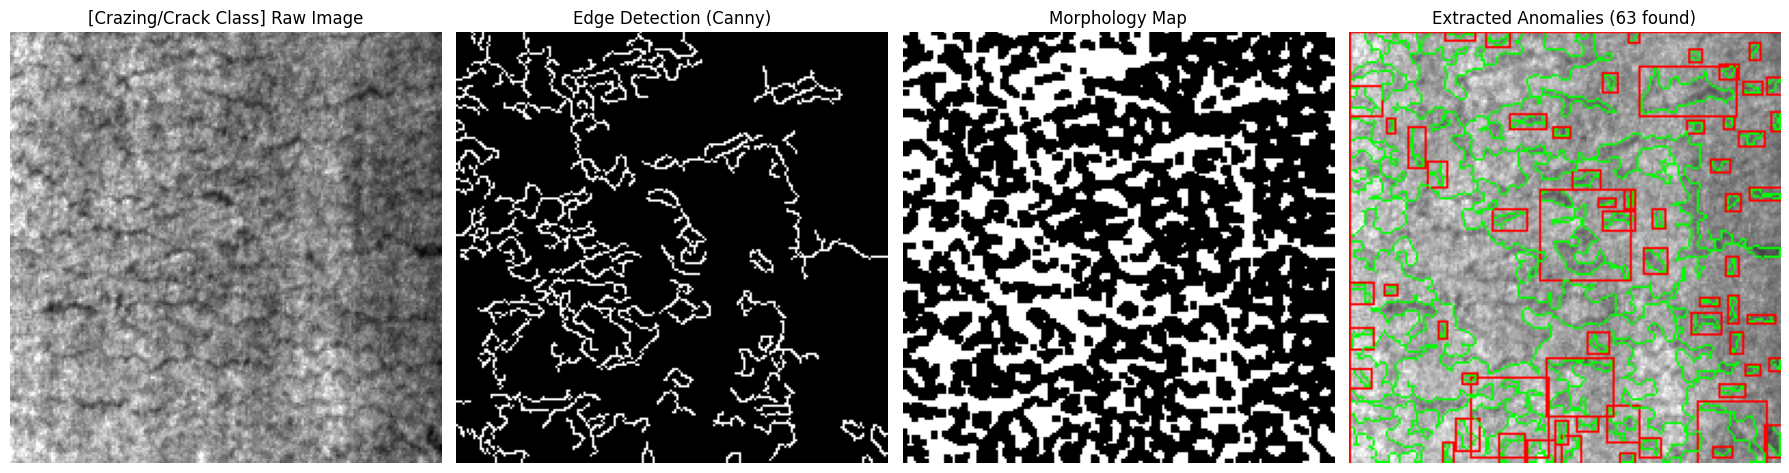

In [3]:
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DOWNLOAD SAMPLE IMAGES FROM NEU DATASET
# ==========================================
print("Fetching real metal defect images from NEU dataset source...")

# Sample images representing scratches and cracks from a verified NEU-DET project repo
urls = {
    "scratch_sample.jpg": "https://raw.githubusercontent.com/siddhartamukherjee/NEU-DET-Steel-Surface-Defect-Detection/master/IMAGES/scratch_1.jpg",
    "crack_sample.jpg": "https://raw.githubusercontent.com/siddhartamukherjee/NEU-DET-Steel-Surface-Defect-Detection/master/IMAGES/crazing_1.jpg"
}

for filename, url in urls.items():
    if not os.path.exists(filename):
        try:
            urllib.request.urlretrieve(url, filename)
            print(f" Successfully downloaded: {filename}")
        except Exception as e:
            print(f" Error downloading {filename}: {e}")
    else:
        print(f" {filename} already exists locally.")

# ==========================================
# 2. DEFECT DETECTION PROCESSING PIPELINE
# ==========================================
def process_metal_defect(image_path, title_prefix=""):
    # Load image as Grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not load {image_path}")
        return

    # Step A: Bilateral filter to smooth out heavy steel rolling textures while keeping crack boundaries sharp
    blurred = cv2.bilateralFilter(img, d=7, sigmaColor=65, sigmaSpace=65)

    # Step B: Contrast Adjustment & Adaptive Thresholding
    # Since factory light drops over distances, we calculate the local threshold per 11x11 block
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 4
    )

    # Step C: Canny Edge Detection to accurately track fine lines
    edges = cv2.Canny(blurred, 40, 120)

    # Combine thresholding and edge detection masks for robust coverage
    combined_mask = cv2.bitwise_or(thresh, edges)

    # Step D: Morphological Cleanup (Close small micro-gaps within cracks)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    cleaned_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)

    # Step E: Contour Extraction
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw identified contours on a colored version of original image
    output_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    defect_count = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        # Filter out negligible pixel artifacts (dust/grain noise)
        if area > 12:
            # Bounding rectangle around defects
            x, y, w, h = cv2.boundingRect(cnt)

            # Highlight contour paths in green and boxes in red
            cv2.drawContours(output_bgr, [cnt], -1, (0, 255, 0), 1)
            cv2.rectangle(output_bgr, (x, y), (x+w, y+h), (0, 0, 255), 1)
            defect_count += 1

    # --- Plotting the Stage Outputs ---
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f"{title_prefix} Raw Image")
    axes[0].axis('off')

    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title("Edge Detection (Canny)")
    axes[1].axis('off')

    axes[2].imshow(cleaned_mask, cmap='gray')
    axes[2].set_title("Morphology Map")
    axes[2].axis('off')

    axes[3].imshow(cv2.cvtColor(output_bgr, cv2.COLOR_BGR2RGB))
    axes[3].set_title(f"Extracted Anomalies ({defect_count} found)")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. RUN PIPELINE ON REAL DEFECT TYPES
# ==========================================
if os.path.exists("scratch_sample.jpg"):
    process_metal_defect("scratch_sample.jpg", title_prefix="[Scratch Class]")

if os.path.exists("crack_sample.jpg"):
    process_metal_defect("crack_sample.jpg", title_prefix="[Crazing/Crack Class]")